<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/Indian_Liver_Patient_Prediction_Using_Decision_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
import pandas as pd

# Step 2: Load the dataset
data = pd.read_csv('Indian Liver Patient Dataset (ILPD).csv')
data.head()

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
# Step 3: Handle missing values
# Check for missing values in the dataset
data.isnull().sum()


,0
age,0
gender,0
tot_bilirubin,0
direct_bilirubin,0
tot_proteins,0
albumin,0
ag_ratio,0
sgpt,0
sgot,0
alkphos,4


In [ ]:
# Fill missing values in 'alkphos' with median
data['alkphos'].fillna(data['alkphos'].median(), inplace=True)

/tmp/ipykernel_15182/4014573505.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['alkphos'].fillna(data['alkphos'].median(), inplace=True)


In [ ]:
print(data['gender'].isnull().sum())

0


In [ ]:
#convert categorical into numerical
le=LabelEncoder()
data['gender']=le.fit_transform(data['gender'])

In [ ]:
#seperate features and target
X=data.drop('is_patient',axis=1)
y=data['is_patient']

In [ ]:
#convert target variables
y=y.map({1:1,2:0})

In [ ]:
# Step 5: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Step 6: Train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [ ]:
# Step 7: Make predictions on the test set
y_pred = dt_model.predict(X_test)


In [ ]:
# Step 8: Evaluate the model using confusion matrix and accuracy
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
# Print results
print("Confusion Matrix:")
print(cm)
print("\nAccuracy Score:", accuracy)


Confusion Matrix:
[[24 23]
 [31 97]]

Accuracy Score: 0.6914285714285714


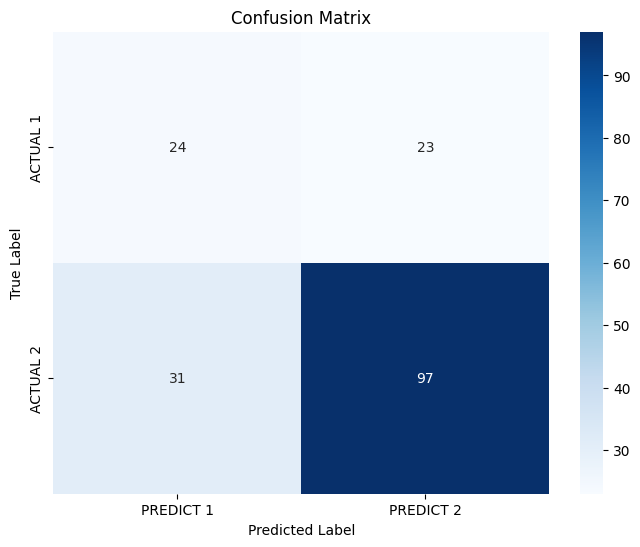

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['PREDICT 1','PREDICT 2'],
            yticklabels=['ACTUAL 1','ACTUAL 2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()